In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
df = pd.read_csv("test_Y3wMUE5_7gLdaTN.csv")
df.columns = df.columns.str.strip()

print(df.columns)
print(df.head())

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='str')
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001015   Male     Yes          0      Graduate            No   
1  LP001022   Male     Yes          1      Graduate            No   
2  LP001031   Male     Yes          2      Graduate            No   
3  LP001035   Male     Yes          2      Graduate            No   
4  LP001051   Male      No          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5720                  0       110.0             360.0   
1             3076               1500       126.0             360.0   
2             5000               1800       208.0             360.0   
3             2340               2546       100.0             360.0   
4   

In [10]:
# Check missing values
print(df.isnull().sum())

# Fill missing values
df.fillna(df.mode().iloc[0], inplace=True)

# Create Total Income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Log transformation (reduce skewness)
df['Log_Income'] = np.log1p(df['Total_Income'])
df['Log_LoanAmount'] = np.log1p(df['LoanAmount'])

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


In [11]:
print("Skewness Before Transformation:")
print(df[['ApplicantIncome','LoanAmount']].skew())

print("Skewness After Transformation:")
print(df[['Log_Income','Log_LoanAmount']].skew())

Skewness Before Transformation:
ApplicantIncome    8.441375
LoanAmount         2.227162
dtype: float64
Skewness After Transformation:
Log_Income        1.172348
Log_LoanAmount   -0.244734
dtype: float64


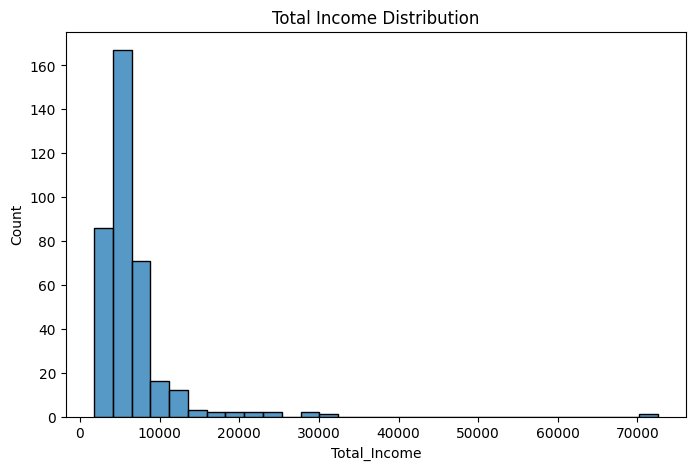

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Income'], bins=30)
plt.title("Total Income Distribution")
plt.show()

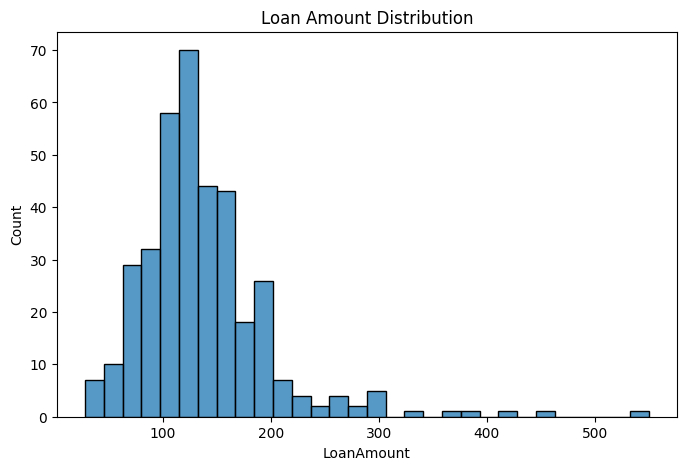

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=30)
plt.title("Loan Amount Distribution")
plt.show()

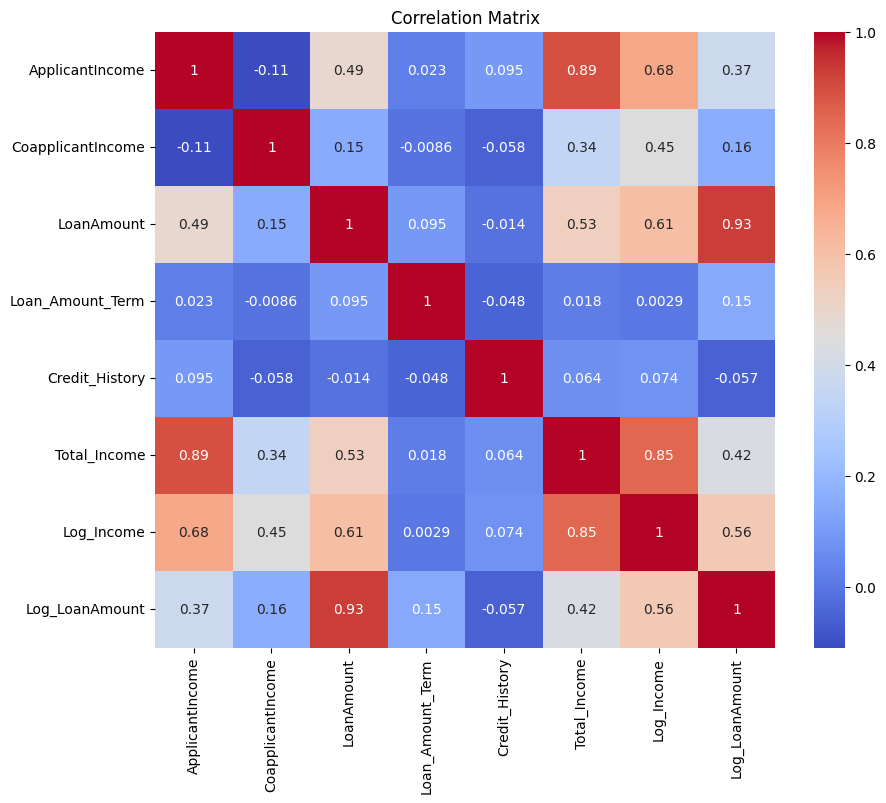

In [14]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

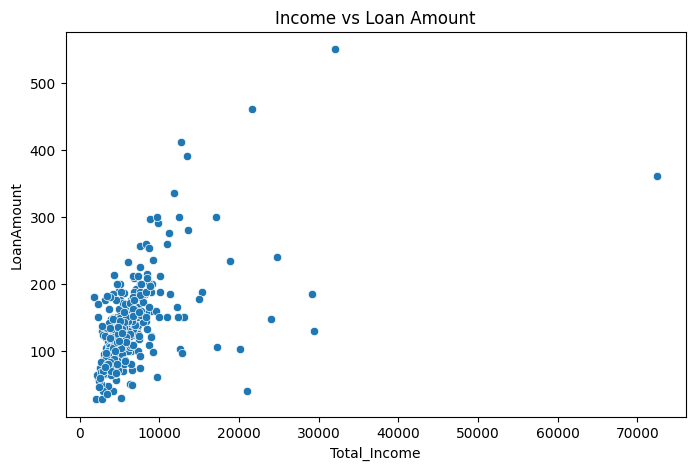

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Total_Income', y='LoanAmount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

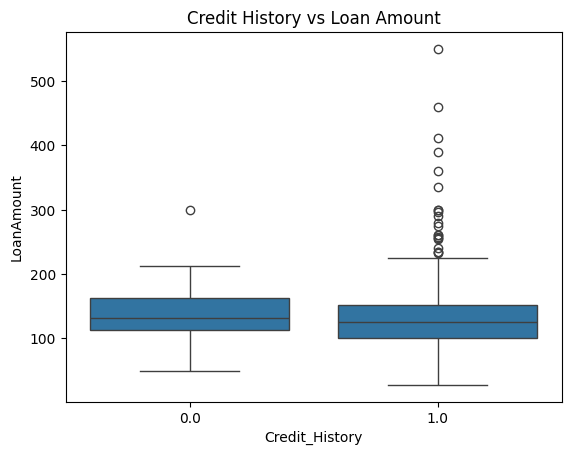

In [16]:
sns.boxplot(x='Credit_History', y='LoanAmount', data=df)
plt.title("Credit History vs Loan Amount")
plt.show()

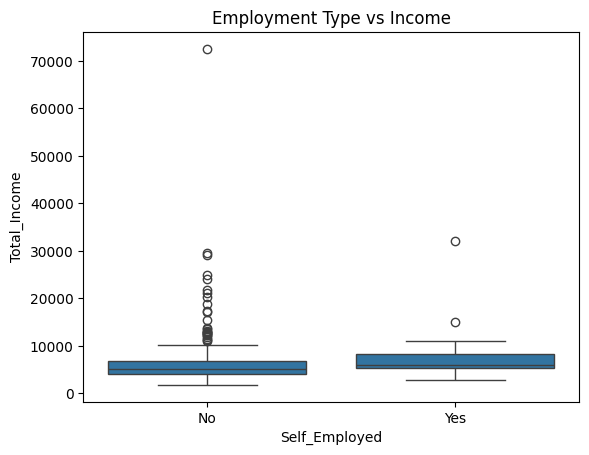

In [17]:
sns.boxplot(x='Self_Employed', y='Total_Income', data=df)
plt.title("Employment Type vs Income")
plt.show()

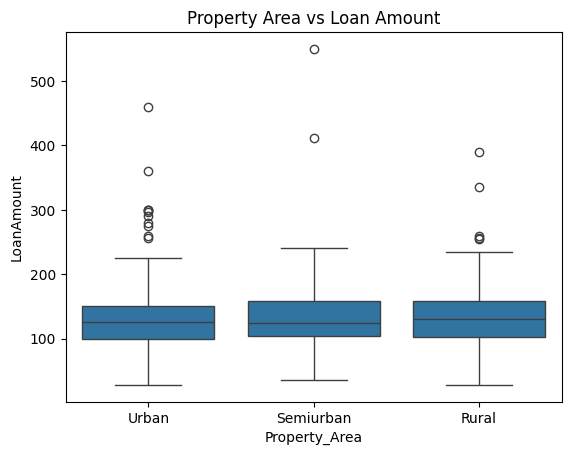

In [18]:
sns.boxplot(x='Property_Area', y='LoanAmount', data=df)
plt.title("Property Area vs Loan Amount")
plt.show()

In [19]:
df['Income_Quartile'] = pd.qcut(df['Total_Income'], 4)

print(df.groupby('Income_Quartile')['LoanAmount'].mean())

Income_Quartile
(1759.999, 4156.0]    100.380435
(4156.0, 5205.0]      121.086957
(5205.0, 6980.0]      133.208791
(6980.0, 72529.0]     190.576087
Name: LoanAmount, dtype: float64


In [20]:
correlation, p_value = stats.pearsonr(df['Total_Income'], df['LoanAmount'])

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.531745706724827
P-value: 3.559020744576931e-28


In [21]:
df['Risk_Level'] = np.where(
    (df['Credit_History']==1) & (df['Total_Income']>5000),
    "Low Risk",
    "High Risk"
)

print(df['Risk_Level'].value_counts())

Risk_Level
High Risk    197
Low Risk     170
Name: count, dtype: int64


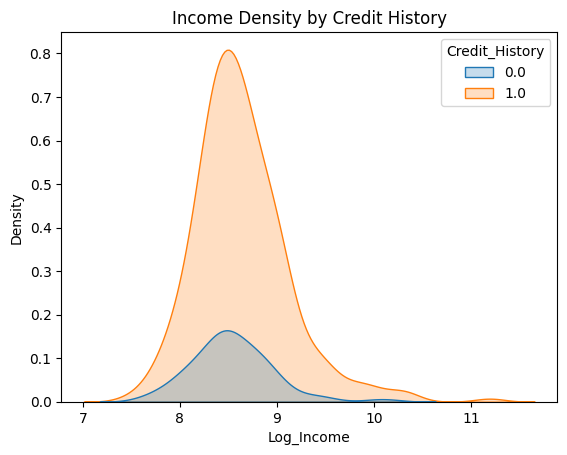

In [22]:
sns.kdeplot(data=df, x='Log_Income', hue='Credit_History', fill=True)
plt.title("Income Density by Credit History")
plt.show()